<a href="https://colab.research.google.com/github/BrunaLimaa/ImgSegmentation-IC/blob/SDUAISHD/notebooks/03_DeepLabv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import torch
import torchvision
from torchvision.transforms import functional as F
from PIL import Image
import requests
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

Carregando o modelo pré-treinado DeepLabV3...
Modelo carregado com sucesso!
Realizando a predição...
Predição concluída!


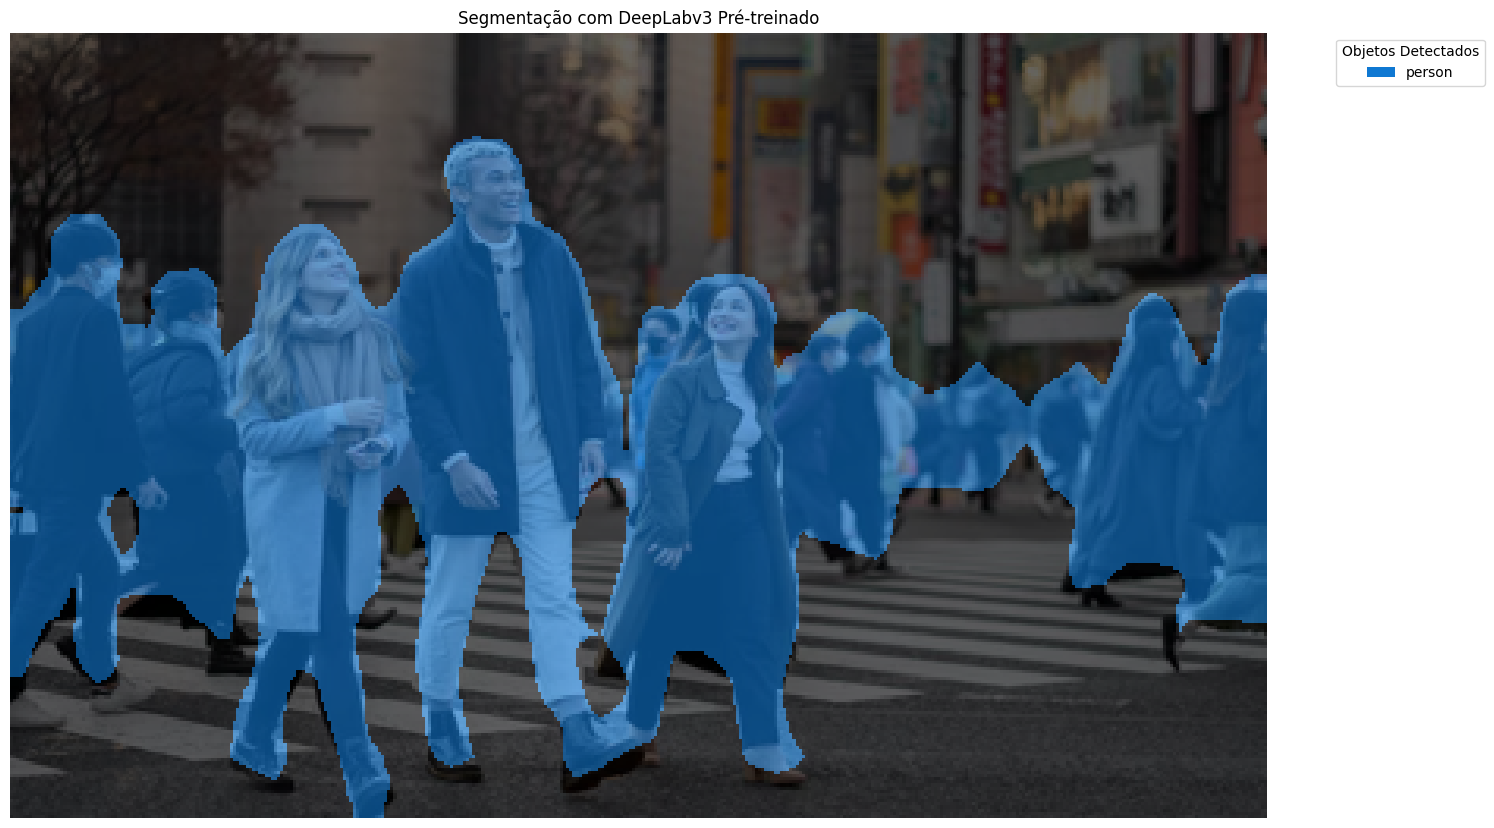

In [12]:
# --- EXERCÍCIO 3: SEGMENTAÇÃO COM DEEP LEARNING ---

print("Carregando o modelo pré-treinado DeepLabV3...")
model = torchvision.models.segmentation.deeplabv3_resnet101(weights='DEFAULT')
model.eval()
print("Modelo carregado com sucesso!")

COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]


# Carrega a Imagem de Entrada
try:
    input_image = Image.open("/content/people-street.jpg").convert("RGB")
except Exception as e:
    print(f"Erro ao carregar a imagem")
    # Se a imagem falhar, cria uma imagem de teste para o código não quebrar
    input_image = Image.fromarray((np.random.rand(400, 600, 3) * 255).astype('uint8')).convert('RGB')

input_image = input_image.resize((400, 250))

# Converte a imagem de um objeto PIL para um Tensor do PyTorch.
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(input_image)

input_batch = input_tensor.unsqueeze(0)

print("Realizando a predição...")

if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    model.to('cuda')

with torch.no_grad():
    output = model(input_batch)['out'][0]

output_predictions = output.argmax(0)
print("Predição concluída!")


mask = output_predictions.byte().cpu().numpy()

# Cria uma paleta de cores para colorir cada classe de objeto.(fundo, avião, pessoa, carro, cachorro, etc.)
palette = torch.tensor([2 ** 25 - 1, 2 ** 15 - 1, 2 ** 21 - 1])
colors = torch.as_tensor([i for i in range(21)])[:, None] * palette
colors = (colors % 255).numpy().astype("uint8")

# Converte a máscara de predição em uma imagem RGB colorida.
result_mask_rgb = Image.fromarray(mask).convert("P")
result_mask_rgb.putpalette(colors)

detected_ids = np.unique(mask)

legend_elements = []
for class_id in detected_ids:
    if class_id == 0:
        continue

    class_name = COCO_INSTANCE_CATEGORY_NAMES[class_id]
    color = colors[class_id] / 255.0
    patch = Patch(facecolor=color, label=class_name)
    legend_elements.append(patch)



fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(input_image)
ax.imshow(result_mask_rgb, alpha=0.6)


ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', title="Objetos Detectados")

ax.axis('off')
plt.title("Segmentação com DeepLabv3 Pré-treinado")
plt.tight_layout()
plt.show()